<a href="https://colab.research.google.com/github/hazelosijaja23/Impact-of-Ai-on-Students-classification-burnout/blob/main/impact-of-ia-on-students-classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Descargar la última versión del dataset
path = kagglehub.dataset_download("laveshjadon/ai-impact-on-students")
print("Ruta de los archivos del dataset:", path)

Using Colab cache for faster access to the 'ai-impact-on-students' dataset.
Ruta de los archivos del dataset: /kaggle/input/ai-impact-on-students


In [2]:
# Cargar el dataset a un DataFrame de pandas
csv_file = os.path.join(path, os.listdir(path)[0])
data = pd.read_csv(csv_file)

print("Dimensiones del dataset:", data.shape)
print("\nPrimeras filas del conjunto de datos:")
display(data.head())
print("\nLista de columnas originales:", data.columns.tolist())

Dimensiones del dataset: (50000, 16)

Primeras filas del conjunto de datos:


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium



Lista de columnas originales: ['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level']


In [3]:
# 1. Ratio de Dependencia Tecnológica
data['AI_Study_Ratio'] = data['Weekly_GenAI_Hours'] / (data['Traditional_Study_Hours'] + 1)

# 2. Impacto en el Rendimiento (GPA Delta)
data['GPA_Delta'] = data['Post_Semester_GPA'] - data['Pre_Semester_GPA']

# 3. Carga de Estrés Combinada (Estrés por Dependencia)
data['Stress_AI_Load'] = data['Anxiety_Level_During_Exams'] * data['Perceived_AI_Dependency']

print("¡Nuevas características compuestas creadas con éxito!")
display(data[['Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'AI_Study_Ratio', 'GPA_Delta', 'Stress_AI_Load']].head())

¡Nuevas características compuestas creadas con éxito!


,Weekly_GenAI_Hours,Traditional_Study_Hours,AI_Study_Ratio,GPA_Delta,Stress_AI_Load
0,23.31,8.13,2.553122,-0.025,30
1,1.12,16.65,0.063456,-0.125,27
2,21.26,10.35,1.873128,0.101,45
3,1.82,15.23,0.112138,0.211,4
4,9.29,12.55,0.685609,0.163,16


In [4]:
# Verificación de datos faltantes
datos_faltantes = data.isnull().sum()
print("Valores faltantes por columna:")
print(datos_faltantes)
print("\nTotal de valores faltantes:", datos_faltantes.sum())

# Análisis de variables categóricas
datos_categoricos = data.select_dtypes(include="object")
for columna in datos_categoricos:
    print(f"\nDistribución de frecuencias para: {columna}")
    print(data[columna].value_counts(dropna=False))

Valores faltantes por columna:
Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
AI_Study_Ratio                0
GPA_Delta                     0
Stress_AI_Load                0
dtype: int64

Total de valores faltantes: 0

Distribución de frecuencias para: Major_Category
Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

Distribución de frecuencias para: Year_of_Study
Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophom

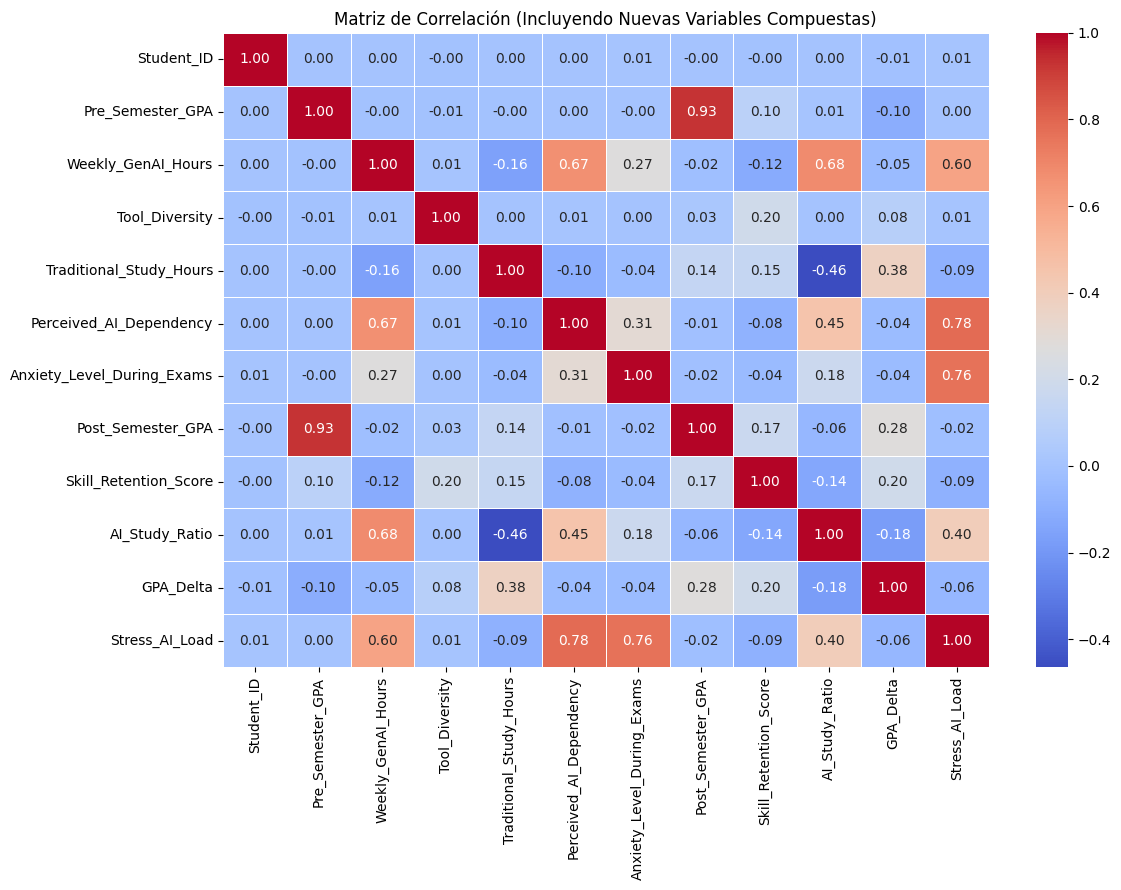

In [5]:
# Seleccionar columnas numéricas automáticas incluyendo las nuevas creadas
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12, 9))
sns.heatmap(
    data[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Matriz de Correlación (Incluyendo Nuevas Variables Compuestas)")
plt.tight_layout()
plt.show()

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identificar la variable objetivo (target) y remover identificadores inútiles
target_col = 'Burnout_Risk_Level'
X = data.drop(columns=[target_col, 'Student_ID'])
y = data[target_col]

# Separar variables numéricas y categóricas para el pipeline
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'bool']).columns

# Crear el preprocesador estructurado
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("Proporción de las clases de Burnout:")
print(y.value_counts(normalize=True) * 100)

Proporción de las clases de Burnout:
Burnout_Risk_Level
Medium    42.288
Low       32.738
High      24.974
Name: proportion, dtype: float64


/tmp/ipykernel_3030/3425739150.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


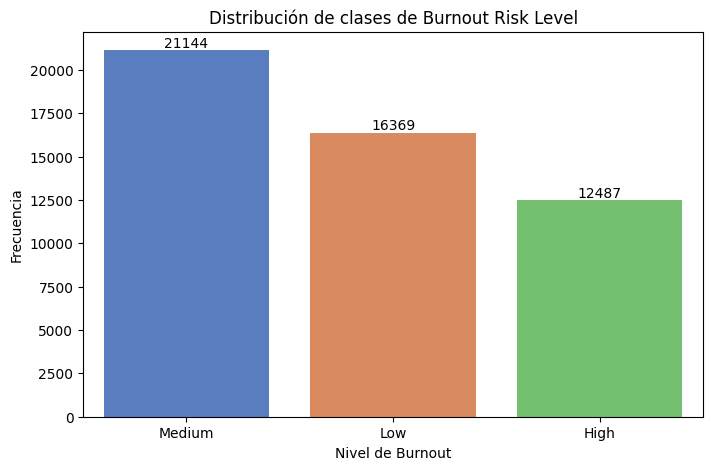

In [7]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    x=y,
    order=y.value_counts().index,
    palette="muted"
)

# Añadir etiquetas con los conteos exactos sobre las barras
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribución de clases de Burnout Risk Level")
plt.xlabel("Nivel de Burnout")
plt.ylabel("Frecuencia")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

# División manteniendo las mismas proporciones de clase
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Registros de entrenamiento (X_train): {X_train.shape[0]}")
print(f"Registros de prueba (X_test): {X_test.shape[0]}")

Registros de entrenamiento (X_train): 40000
Registros de prueba (X_test): 10000


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Definición del Pipeline con balanceo de clases
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Definición de la rejilla de parámetros
param_grid_lr = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['lbfgs', 'saga']
}

# Inicialización de la búsqueda en cuadrícula con Validación Cruzada (CV=5)
grid_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid_lr,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Ajuste del modelo
grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_

print("\n--- Resultados Regresión Logística ---")
print("Mejores parámetros encontrados:", grid_lr.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

--- Resultados Regresión Logística ---
Mejores parámetros encontrados: {'classifier__C': 0.01, 'classifier__solver': 'saga'}


In [10]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

pred_lr = best_lr.predict(X_test)

print("=== REPORTE DE CLASIFICACIÓN - REGRESIÓN LOGÍSTICA ===")
print(classification_report(y_test, pred_lr))

print(f"Accuracy: {accuracy_score(y_test, pred_lr):.4f}")
print(f"Precision (Weighted): {precision_score(y_test, pred_lr, average='weighted'):.4f}")
print(f"Recall (Weighted): {recall_score(y_test, pred_lr, average='weighted'):.4f}")
print(f"F1 Score (Weighted): {f1_score(y_test, pred_lr, average='weighted'):.4f}")

=== REPORTE DE CLASIFICACIÓN - REGRESIÓN LOGÍSTICA ===
              precision    recall  f1-score   support

        High       0.54      0.62      0.58      2497
         Low       0.50      0.68      0.58      3274
      Medium       0.50      0.32      0.39      4229

    accuracy                           0.51     10000
   macro avg       0.51      0.54      0.52     10000
weighted avg       0.51      0.51      0.50     10000

Accuracy: 0.5127
Precision (Weighted): 0.5113
Recall (Weighted): 0.5127
F1 Score (Weighted): 0.4988


In [11]:
from sklearn.ensemble import RandomForestClassifier

# Definición del Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=20, class_weight='balanced_subsample'))
])

# Rejilla extendida basada en tus combinaciones candidatos
param_grid_rf = {
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__min_samples_split': [2, 5],
    'classifier__n_estimators': [100, 300]
}

# Configuración del GridSearch
grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Ajuste del modelo
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

print("\n--- Resultados Random Forest ---")
print("Mejores parámetros encontrados:", grid_rf.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



--- Resultados Random Forest ---
Mejores parámetros encontrados: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}


In [12]:
pred_rf = best_rf.predict(X_test)

print("=== REPORTE DE CLASIFICACIÓN - RANDOM FOREST ===")
print(classification_report(y_test, pred_rf))

print(f"Accuracy: {accuracy_score(y_test, pred_rf):.4f}")
print(f"Precision (Weighted): {precision_score(y_test, pred_rf, average='weighted'):.4f}")
print(f"Recall (Weighted): {recall_score(y_test, pred_rf, average='weighted'):.4f}")
print(f"F1 Score (Weighted): {f1_score(y_test, pred_rf, average='weighted'):.4f}")

=== REPORTE DE CLASIFICACIÓN - RANDOM FOREST ===
              precision    recall  f1-score   support

        High       0.63      0.51      0.56      2497
         Low       0.52      0.54      0.53      3274
      Medium       0.49      0.52      0.50      4229

    accuracy                           0.53     10000
   macro avg       0.54      0.53      0.53     10000
weighted avg       0.53      0.53      0.53     10000

Accuracy: 0.5262
Precision (Weighted): 0.5321
Recall (Weighted): 0.5262
F1 Score (Weighted): 0.5274


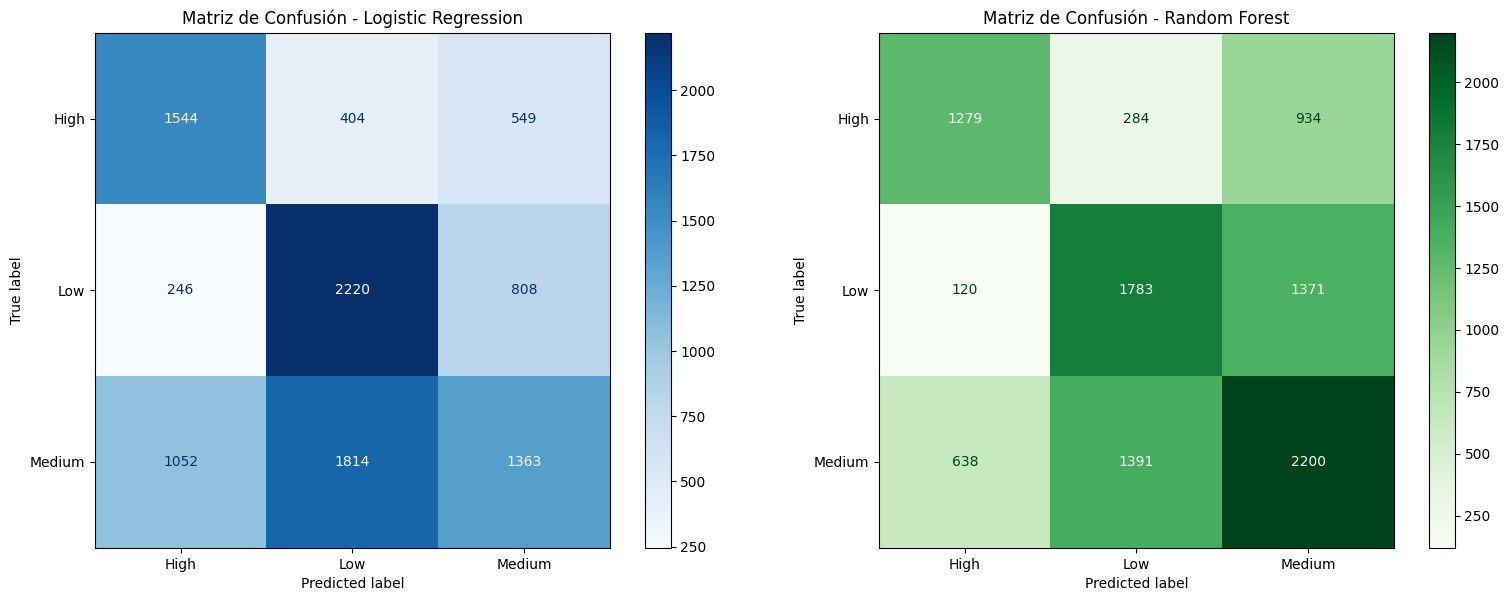

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz 1: Regresión Logística
cm_lr = confusion_matrix(y_test, pred_lr, labels=best_lr.classes_)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=best_lr.classes_)
disp_lr.plot(cmap='Blues', ax=axes[0])
axes[0].set_title("Matriz de Confusión - Logistic Regression")

# Matriz 2: Random Forest
cm_rf = confusion_matrix(y_test, pred_rf, labels=best_rf.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=best_rf.classes_)
disp_rf.plot(cmap='Greens', ax=axes[1])
axes[1].set_title("Matriz de Confusión - Random Forest")

plt.tight_layout()
plt.show()

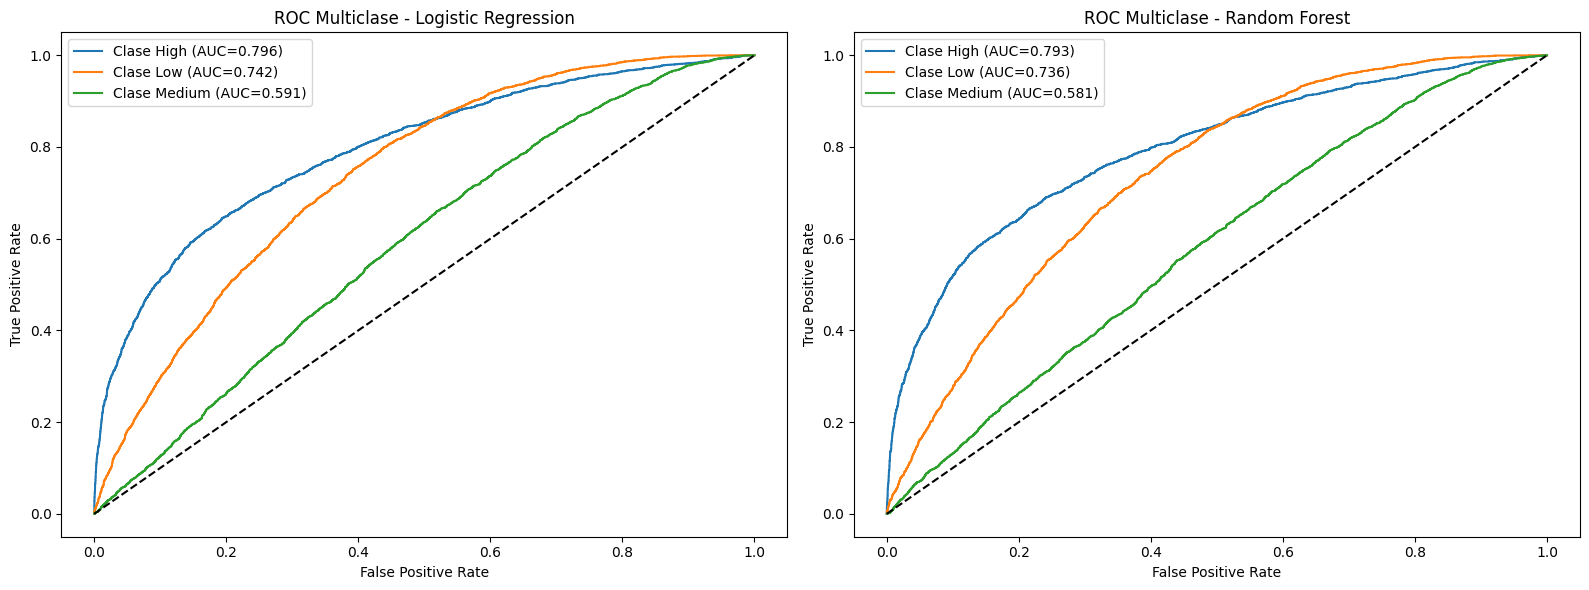

In [14]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = best_lr.classes_
y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Curva ROC - Regresión Logística
y_score_lr = best_lr.predict_proba(X_test)
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_lr[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f"Clase {classes[i]} (AUC={roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Multiclase - Logistic Regression")
axes[0].legend()

# Curva ROC - Random Forest
y_score_rf = best_rf.predict_proba(X_test)
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_rf[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f"Clase {classes[i]} (AUC={roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Multiclase - Random Forest")
axes[1].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_3030/134007104.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


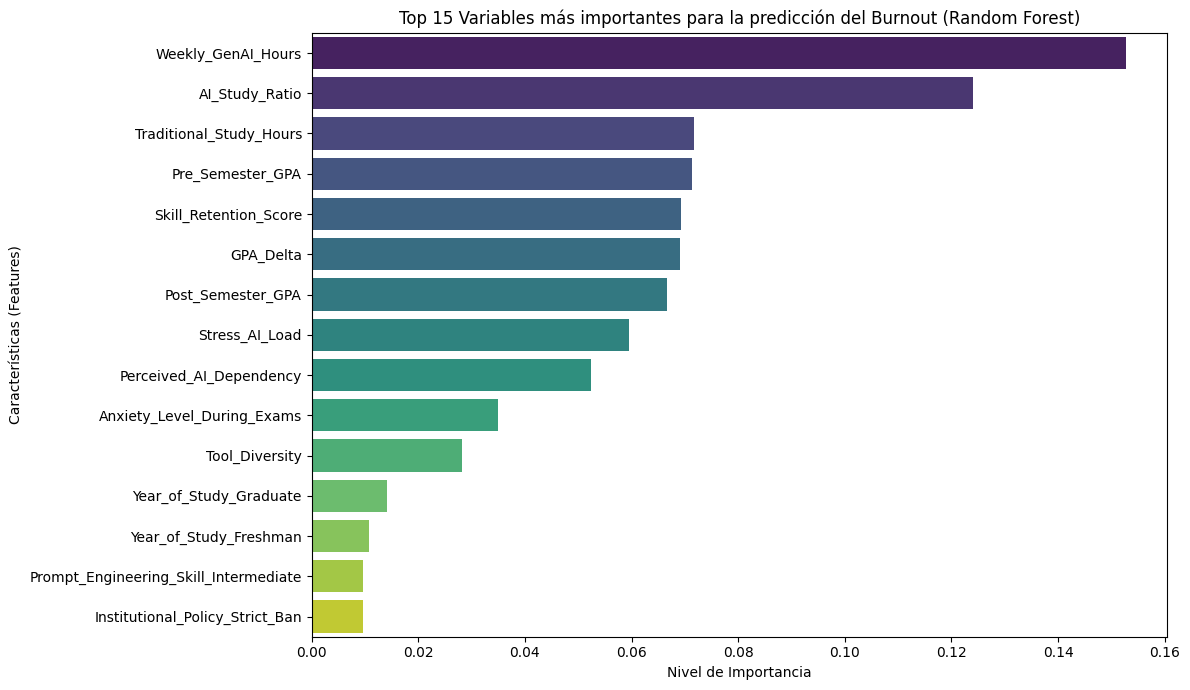

In [15]:
# Extraer los nombres de las columnas transformadas por el OneHotEncoder y StandardScaler
feature_names = (
    numeric_features.tolist() +
    best_rf.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
    .tolist()
)

# Obtener importancias del clasificador entrenado
importances = best_rf.named_steps['classifier'].feature_importances_

# Crear DataFrame organizando los datos de mayor a menor importancia
importance_df = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=False)

# Graficar las 15 variables más relevantes
plt.figure(figsize=(12, 7))
sns.barplot(
    data=importance_df.head(15),
    x='Importancia',
    y='Variable',
    palette="viridis"
)
plt.title("Top 15 Variables más importantes para la predicción del Burnout (Random Forest)")
plt.xlabel("Nivel de Importancia")
plt.ylabel("Características (Features)")
plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import f1_score, accuracy_score

# --- REGRESIÓN LOGÍSTICA ---
# 1. Métricas de Entrenamiento
pred_lr_train = best_lr.predict(X_train)
lr_train_acc = accuracy_score(y_train, pred_lr_train)
lr_train_f1 = f1_score(y_train, pred_lr_train, average='weighted')

# 2. Métricas de Validación (Promedio de los 5-folds del GridSearch)
best_index_lr = grid_lr.best_index_
lr_val_f1 = grid_lr.cv_results_['mean_test_score'][best_index_lr]
# Nota: GridSearchCV no calcula el accuracy de validación a menos que se configure explícitamente,
# pero usamos el F1-weighted que fue tu métrica de optimización.

# 3. Métricas de Prueba
pred_lr_test = best_lr.predict(X_test)
lr_test_acc = accuracy_score(y_test, pred_lr_test)
lr_test_f1 = f1_score(y_test, pred_lr_test, average='weighted')


# --- RANDOM FOREST ---
# 1. Métricas de Entrenamiento
pred_rf_train = best_rf.predict(X_train)
rf_train_acc = accuracy_score(y_train, pred_rf_train)
rf_train_f1 = f1_score(y_train, pred_rf_train, average='weighted')

# 2. Métricas de Validación (Promedio de los 5-folds del GridSearch)
best_index_rf = grid_rf.best_index_
rf_val_f1 = grid_rf.cv_results_['mean_test_score'][best_index_rf]

# 3. Métricas de Prueba
pred_rf_test = best_rf.predict(X_test)
rf_test_acc = accuracy_score(y_test, pred_rf_test)
rf_test_f1 = f1_score(y_test, pred_rf_test, average='weighted')

print("¡Cálculo de rendimiento completado!")

¡Cálculo de rendimiento completado!


In [17]:
# Crear un DataFrame para estructurar los resultados de forma limpia
resultados_data = {
    'Modelo': ['Regresión Logística', 'Random Forest'],
    'Train Accuracy': [f"{lr_train_acc:.4f}", f"{rf_train_acc:.4f}"],
    'Train F1-Score': [f"{lr_train_f1:.4f}", f"{rf_train_f1:.4f}"],
    'Validation F1-Score (CV)': [f"{lr_val_f1:.4f}", f"{rf_val_f1:.4f}"],
    'Test Accuracy': [f"{lr_test_acc:.4f}", f"{rf_test_acc:.4f}"],
    'Test F1-Score': [f"{lr_test_f1:.4f}", f"{rf_test_f1:.4f}"]
}

df_resultados = pd.DataFrame(resultados_data)

print("=== TABLA COMPARATIVA DE CONJUNTOS ===")
display(df_resultados)

=== TABLA COMPARATIVA DE CONJUNTOS ===


,Modelo,Train Accuracy,Train F1-Score,Validation F1-Score (CV),Test Accuracy,Test F1-Score
0,Regresión Logística,0.5155,0.5008,0.4993,0.5127,0.4988
1,Random Forest,0.9894,0.9894,0.5299,0.5262,0.5274


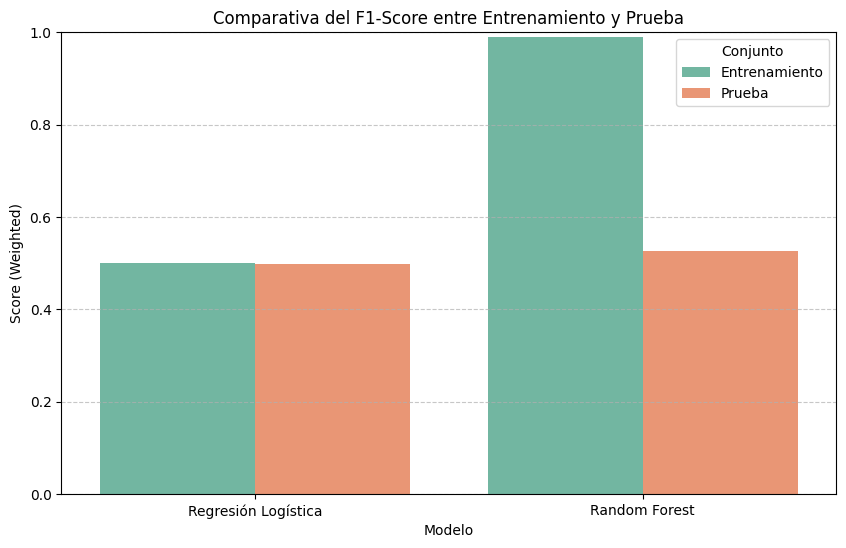

In [18]:
# Preparar los datos para graficar usando formato largo (melt)
plot_data = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Regresión Logística', 'Random Forest', 'Random Forest'],
    'Conjunto': ['Entrenamiento', 'Prueba', 'Entrenamiento', 'Prueba'],
    'F1-Score': [lr_train_f1, lr_test_f1, rf_train_f1, rf_test_f1]
})

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_data,
    x='Modelo',
    y='F1-Score',
    hue='Conjunto',
    palette='Set2'
)

plt.ylim(0, 1.0)
plt.title("Comparativa del F1-Score entre Entrenamiento y Prueba")
plt.ylabel("Score (Weighted)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== PROMEDIO DE VARIABLES POR NIVEL DE BURNOUT ===


,Anxiety_Level_During_Exams,Weekly_GenAI_Hours,Traditional_Study_Hours,GPA_Delta,Stress_AI_Load
Burnout_Risk_Level,,,,,
High,4.889325,15.214823,10.081885,0.195644,24.276768
Low,3.928462,4.643648,11.965504,0.200381,11.639807
Medium,4.170450,7.349047,11.289620,0.209838,14.892972


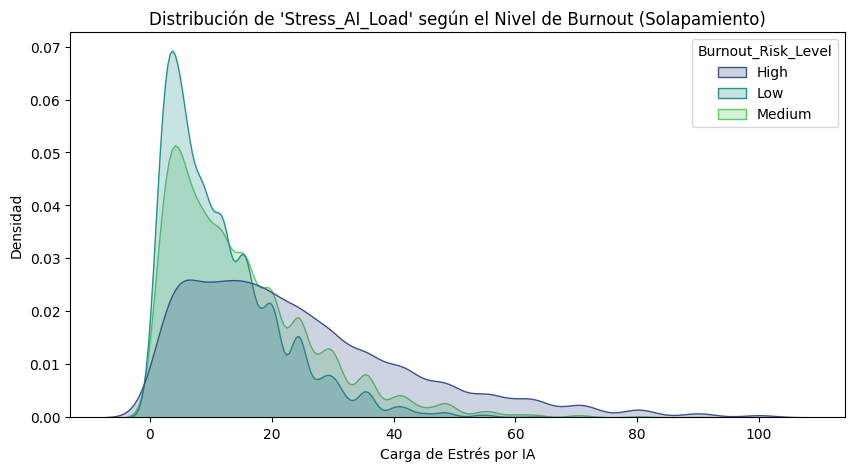

In [19]:
# Agrupar por la variable objetivo y ver los promedios de las variables numéricas clave
print("=== PROMEDIO DE VARIABLES POR NIVEL DE BURNOUT ===")
analisis_clases = data.groupby('Burnout_Risk_Level')[['Anxiety_Level_During_Exams',
                                                     'Weekly_GenAI_Hours',
                                                     'Traditional_Study_Hours',
                                                     'GPA_Delta',
                                                     'Stress_AI_Load']].mean()
display(analisis_clases)

# Visualizar la distribución de una variable clave (ej. Estrés Combinado) por cada clase
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.kdeplot(data=data, x='Stress_AI_Load', hue='Burnout_Risk_Level', fill=True, common_norm=False, palette='viridis')
plt.title("Distribución de 'Stress_AI_Load' según el Nivel de Burnout (Solapamiento)")
plt.xlabel("Carga de Estrés por IA")
plt.ylabel("Densidad")
plt.show()

In [20]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Aplicamos el preprocesamiento de forma manual a X_train para poder usar SMOTE adecuadamente
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Inicializar SMOTE para balancear las clases al 100% en el set de entrenamiento
smote = SMOTE(random_state=42)

# Verificar el antes y después del balanceo
print("Distribución ANTES de SMOTE en entrenamiento:", y_train.value_counts().to_dict())
X_train_res, y_train_res = smote.fit_resample(X_train_preprocessed, y_train)
print("Distribución DESPUÉS de SMOTE en entrenamiento:", y_train_res.value_counts().to_dict())

Distribución ANTES de SMOTE en entrenamiento: {'Medium': 16915, 'Low': 13095, 'High': 9990}
Distribución DESPUÉS de SMOTE en entrenamiento: {'High': 16915, 'Medium': 16915, 'Low': 16915}


In [21]:
# Definir un nuevo Random Forest restrictivo
rf_restrictivo = RandomForestClassifier(random_state=42)

# Definir una nueva malla de parámetros orientada a frenar el sobreajuste
param_grid_anti_overfit = {
    'n_estimators': [150, 250],
    'max_depth': [5, 8, 12],                # Valores bajos para que no memorice
    'min_samples_leaf': [10, 30, 50],       # Evita hojas con pocos datos
    'max_features': ['sqrt', 0.5]           # Usa solo una parte de las variables por árbol
}

# Configurar el GridSearchCV con los datos balanceados por SMOTE
grid_rf_controlado = GridSearchCV(
    estimator=rf_restrictivo,
    param_grid=param_grid_anti_overfit,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Entrenar usando los datos que pasaron por SMOTE
grid_rf_controlado.fit(X_train_res, y_train_res)
best_rf_controlado = grid_rf_controlado.best_estimator_

print("\nMejores parámetros para evitar Overfitting:", grid_rf_controlado.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Mejores parámetros para evitar Overfitting: {'max_depth': 12, 'max_features': 0.5, 'min_samples_leaf': 10, 'n_estimators': 250}


In [22]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Predicciones con el modelo controlado
pred_rf_res_train = best_rf_controlado.predict(X_train_res)
pred_rf_res_test = best_rf_controlado.predict(X_test_preprocessed)

# Calcular métricas
train_acc_nuevo = accuracy_score(y_train_res, pred_rf_res_train)
train_f1_nuevo = f1_score(y_train_res, pred_rf_res_train, average='weighted')
test_acc_nuevo = accuracy_score(y_test, pred_rf_res_test)
test_f1_nuevo = f1_score(y_test, pred_rf_res_test, average='weighted')

# Crear tabla comparativa
nuevo_resultado = pd.DataFrame({
    'Métrica': ['Accuracy', 'F1-Score (Weighted)'],
    'Nuevo Train (SMOTE + Regulado)': [f"{train_acc_nuevo:.4f}", f"{train_f1_nuevo:.4f}"],
    'Nuevo Test': [f"{test_acc_nuevo:.4f}", f"{test_f1_nuevo:.4f}"]
})

print("=== NUEVOS RESULTADOS DE RANDOM FOREST CONTROLADO ===")
display(nuevo_resultado)

=== NUEVOS RESULTADOS DE RANDOM FOREST CONTROLADO ===


,Métrica,Nuevo Train (SMOTE + Regulado),Nuevo Test
0,Accuracy,0.6838,0.5272
1,F1-Score (Weighted),0.6831,0.5253


In [27]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Predicciones con el modelo controlado
pred_rf_res_train = best_rf_controlado.predict(X_train_res)
pred_rf_res_test = best_rf_controlado.predict(X_test_preprocessed)

# Calcular métricas
train_acc_nuevo = accuracy_score(y_train_res, pred_rf_res_train)
train_f1_nuevo = f1_score(y_train_res, pred_rf_res_train, average='weighted')
test_acc_nuevo = accuracy_score(y_test, pred_rf_res_test)
test_f1_nuevo = f1_score(y_test, pred_rf_res_test, average='weighted')

# Crear tabla comparativa
nuevo_resultado = pd.DataFrame({
    'Métrica': ['Accuracy', 'F1-Score (Weighted)'],
    'Nuevo Train (SMOTE + Regulado)': [f"{train_acc_nuevo:.4f}", f"{train_f1_nuevo:.4f}"],
    'Nuevo Test': [f"{test_acc_nuevo:.4f}", f"{test_f1_nuevo:.4f}"]
})

print("=== NUEVOS RESULTADOS DE RANDOM FOREST CONTROLADO ===")
display(nuevo_resultado)

=== NUEVOS RESULTADOS DE RANDOM FOREST CONTROLADO ===


,Métrica,Nuevo Train (SMOTE + Regulado),Nuevo Test
0,Accuracy,0.6838,0.5272
1,F1-Score (Weighted),0.6831,0.5253


In [31]:
#prueba
import scipy.stats as stats
import numpy as np

print("=== PRUEBA ESTADÍSTICA DE DISCRIMINACIÓN (ANOVA) ===")
for col in ['Anxiety_Level_During_Exams', 'Traditional_Study_Hours', 'GPA_Delta']:
    # Agrupar los datos por cada clase
    group_high = data[data['Burnout_Risk_Level'] == 'High'][col]
    group_low = data[data['Burnout_Risk_Level'] == 'Low'][col]
    group_medium = data[data['Burnout_Risk_Level'] == 'Medium'][col]

    # Calcular ANOVA
    f_stat, p_val = stats.f_oneway(group_high, group_low, group_medium)

    # Calcular Tamaño del Efecto aproximado (Eta cuadrado)
    # Refleja qué porcentaje de la variación del Burnout se explica por esta variable
    all_groups = np.concatenate([group_high, group_low, group_medium])
    grand_mean = np.mean(all_groups)
    ss_total = np.sum((all_groups - grand_mean)**2)
    ss_between = (len(group_high)*(np.mean(group_high)-grand_mean)**2 +
                  len(group_low)*(np.mean(group_low)-grand_mean)**2 +
                  len(group_medium)*(np.mean(group_medium)-grand_mean)**2)
    eta_sq = ss_between / ss_total

    print(f"\nVariable: {col}")
    print(f"  - P-Valor: {p_val:.4e} (¿Es estadísticamente significativa?)")
    print(f"  - Eta-cuadrado (η²): {eta_sq:.4f} ({eta_sq*100:.2f}% de varianza explicada)")

=== PRUEBA ESTADÍSTICA DE DISCRIMINACIÓN (ANOVA) ===

Variable: Anxiety_Level_During_Exams
  - P-Valor: 0.0000e+00 (¿Es estadísticamente significativa?)
  - Eta-cuadrado (η²): 0.0301 (3.01% de varianza explicada)

Variable: Traditional_Study_Hours
  - P-Valor: 6.6475e-210 (¿Es estadísticamente significativa?)
  - Eta-cuadrado (η²): 0.0191 (1.91% de varianza explicada)

Variable: GPA_Delta
  - P-Valor: 9.9342e-12 (¿Es estadísticamente significativa?)
  - Eta-cuadrado (η²): 0.0010 (0.10% de varianza explicada)


In [32]:
from sklearn.metrics import davies_bouldin_score, silhouette_score
import numpy as np

# Tomamos una muestra aleatoria para acelerar el cálculo matemático de la silueta
np.random.seed(42)
indices_muestra = np.random.choice(X_train_preprocessed.shape[0], size=5000, replace=False)
X_sample = X_train_preprocessed[indices_muestra]
y_sample = y_train.iloc[indices_muestra]

# Índice Davies-Bouldin: Mide la similitud promedio entre cada clase y su clase más similar.
# Valores más bajos indican mejor separación. Valores altos (> 2.0 o 3.0) significan solapamiento masivo.
db_index = davies_bouldin_score(X_sample, y_sample)

print("=== MÉTRICAS DE GEOMETRÍA DE CLASES ===")
print(f"Índice Davies-Bouldin: {db_index:.4f}")
if db_index > 2.0:
    print("-> Diagnóstico: Las clases están espacialmente incrustadas unas dentro de otras.")

=== MÉTRICAS DE GEOMETRÍA DE CLASES ===
Índice Davies-Bouldin: 8.6813
-> Diagnóstico: Las clases están espacialmente incrustadas unas dentro de otras.


/tmp/ipykernel_3030/199985164.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


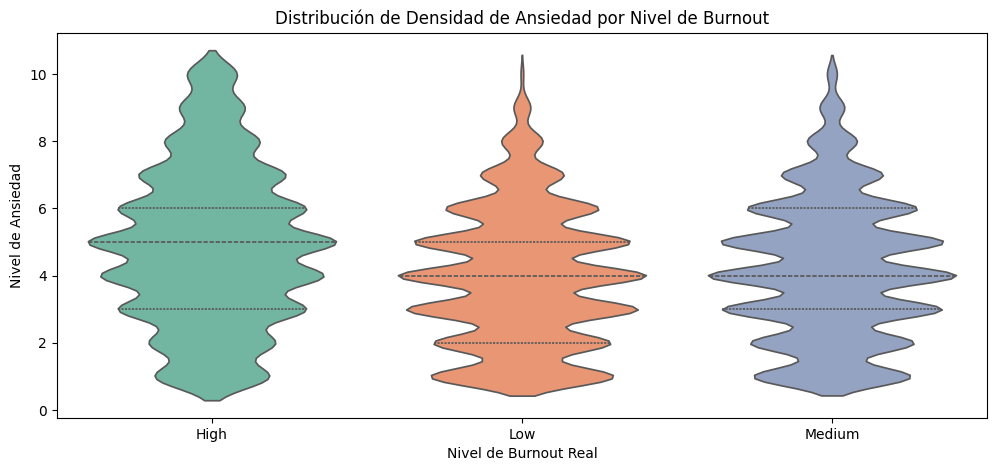

In [33]:
plt.figure(figsize=(12, 5))
sns.violinplot(
    data=data,
    x='Burnout_Risk_Level',
    y='Anxiety_Level_During_Exams',
    palette='Set2',
    inner='quartile'
)
plt.title("Distribución de Densidad de Ansiedad por Nivel de Burnout")
plt.xlabel("Nivel de Burnout Real")
plt.ylabel("Nivel de Ansiedad")
plt.show()

In [1]:
import scipy.stats as stats
import numpy as np

print("=== PRUEBA ESTADÍSTICA DE DISCRIMINACIÓN (ANOVA) ===")
for col in ['Anxiety_Level_During_Exams', 'Traditional_Study_Hours', 'GPA_Delta']:
    # Agrupar los datos por cada clase
    group_high = data[data['Burnout_Risk_Level'] == 'High'][col]
    group_low = data[data['Burnout_Risk_Level'] == 'Low'][col]
    group_medium = data[data['Burnout_Risk_Level'] == 'Medium'][col]

    # Calcular ANOVA
    f_stat, p_val = stats.f_oneway(group_high, group_low, group_medium)

    # Calcular Tamaño del Efecto aproximado (Eta cuadrado)
    # Refleja qué porcentaje de la variación del Burnout se explica por esta variable
    all_groups = np.concatenate([group_high, group_low, group_medium])
    grand_mean = np.mean(all_groups)
    ss_total = np.sum((all_groups - grand_mean)**2)
    ss_between = (len(group_high)*(np.mean(group_high)-grand_mean)**2 +
                  len(group_low)*(np.mean(group_low)-grand_mean)**2 +
                  len(group_medium)*(np.mean(group_medium)-grand_mean)**2)
    eta_sq = ss_between / ss_total

    print(f"\nVariable: {col}")
    print(f"  - P-Valor: {p_val:.4e} (¿Es estadísticamente significativa?)")
    print(f"  - Eta-cuadrado (η²): {eta_sq:.4f} ({eta_sq*100:.2f}% de varianza explicada)")

=== PRUEBA ESTADÍSTICA DE DISCRIMINACIÓN (ANOVA) ===


NameError: name 'data' is not defined